In [1]:
%pip install -q plotly scipy seaborn kaleido scikit-learn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
import os
warnings.filterwarnings('ignore')

np.random.seed(42)
os.makedirs('images', exist_ok=True)
%matplotlib inline
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid', palette='muted')

print(f'NumPy    {np.__version__}')
print(f'Pandas   {pd.__version__}')
print(f'sklearn  loaded')
print('[OK] Entorno listo')

Note: you may need to restart the kernel to use updated packages.
NumPy    1.26.4
Pandas   2.2.3
sklearn  loaded
[OK] Entorno listo


# Función de Pérdida y Optimización: qué significa entrenar un modelo

**Objetivo de aprendizaje:** entender que entrenar un modelo equivale a resolver un
problema de optimización - minimizar una función que mide cuánto se equivoca el modelo.
Este notebook hace visible ese proceso que habitualmente permanece oculto dentro de `fit()`.

**Conceptos cubiertos:**
- Curva de pérdida convexa y concepto de mínimo
- Descenso por gradiente: cómo el modelo "baja la montaña"
- MSE vs MAE: qué penaliza cada función y cuándo elegir una u otra
- Cross-entropy: por qué el logaritmo y qué mide exactamente
- Train loss vs. validation loss: la señal que distingue aprendizaje de memorización

**Conexión con el documento:** este notebook complementa el bloque
"Función objetivo y función de pérdida: qué significa entrenar" situado antes de la
sección 2.1. Todos los conceptos aquí visualizados tienen su definición conceptual en ese bloque.

---

> **Antes de seguir:** cuando un modelo "aprende", ¿qué crees que está calculando
> exactamente en cada paso? ¿Cómo sabe si lo está haciendo mejor o peor que antes?

<details>
<summary>Orientación para el instructor (desplegar tras la reflexión)</summary>

Una respuesta madura menciona: (1) que el modelo tiene alguna forma de medir el error
entre su predicción y la realidad, (2) que ajusta sus parámetros internos en función de
ese error, (3) que el proceso se repite hasta que el error es suficientemente pequeño.

Si nadie responde, preguntar: "Si tuvieras que enseñar a alguien a estimar tiempos de
entrega, ¿cómo sabrías si ha mejorado?"

Señal de comprensión: el alumno menciona alguna forma de comparar predicción con
realidad - aunque sea de forma informal.

</details>

---

## 1. La curva de pérdida: la "montaña" que el modelo tiene que bajar

Antes de ver cómo se optimiza, hay que visualizar qué se optimiza.
Para un modelo con un solo parámetro `w`, la función de pérdida (MSE) dibuja una curva:

- El eje horizontal representa el valor posible del parámetro
- El eje vertical representa el error total del modelo con ese valor

El entrenamiento consiste en encontrar el punto más bajo de esa curva.
En modelos convexos (como la regresión lineal), ese punto es único y siempre alcanzable.

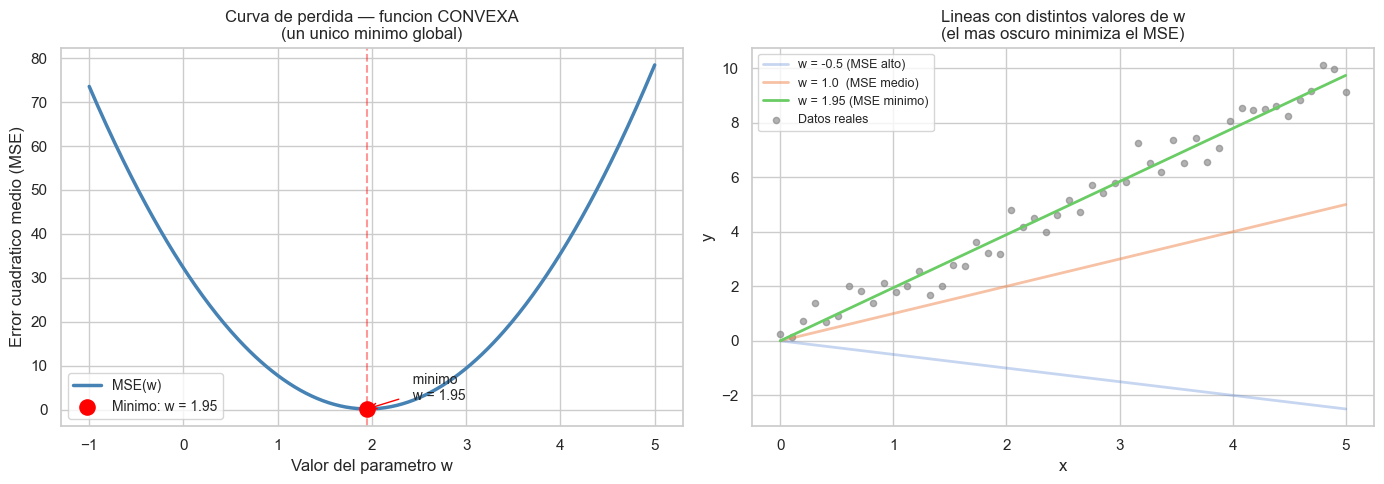

[OK] images/B02B_fig01.png

Parametro optimo (minimo MSE): w = 1.947
Valor real del parametro:      w = 2.000  (el modelo lo encontro)


In [2]:
# Datos de juguete: y real ≈ 2x + ruido
x_toy = np.linspace(0, 5, 50)
y_toy = 2.0 * x_toy + np.random.normal(0, 0.5, 50)

# Función MSE como función de w (barrido de parámetros)
w_vals   = np.linspace(-1, 5, 400)
mse_vals = [np.mean((w * x_toy - y_toy)**2) for w in w_vals]

w_opt    = w_vals[np.argmin(mse_vals)]
mse_opt  = min(mse_vals)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: curva de pérdida convexa
axes[0].plot(w_vals, mse_vals, 'steelblue', linewidth=2.5, label='MSE(w)')
axes[0].scatter([w_opt], [mse_opt], color='red', s=120, zorder=5,
                label=f'Minimo: w = {w_opt:.2f}')
axes[0].axvline(w_opt, color='red', linestyle='--', alpha=0.4)
axes[0].annotate(f'  minimo\n  w = {w_opt:.2f}', xy=(w_opt, mse_opt),
                 xytext=(w_opt + 0.4, mse_opt + 2),
                 arrowprops=dict(arrowstyle='->', color='red'), fontsize=10)
axes[0].set_xlabel('Valor del parametro w')
axes[0].set_ylabel('Error cuadratico medio (MSE)')
axes[0].set_title('Curva de perdida - funcion CONVEXA\n(un unico minimo global)')
axes[0].legend(fontsize=10)

# Panel 2: la línea ajustada en los datos
x_line = np.linspace(0, 5, 100)
for w_demo, alpha, label in [
    (-0.5, 0.3, 'w = -0.5 (MSE alto)'),
    (1.0,  0.5, 'w = 1.0  (MSE medio)'),
    (w_opt, 1.0, f'w = {w_opt:.2f} (MSE minimo)'),
]:
    axes[1].plot(x_line, w_demo * x_line, alpha=alpha,
                 linewidth=2, label=label)
axes[1].scatter(x_toy, y_toy, color='gray', s=20, alpha=0.6, label='Datos reales')
axes[1].set_xlabel('x'); axes[1].set_ylabel('y')
axes[1].set_title('Lineas con distintos valores de w\n(el mas oscuro minimiza el MSE)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('images/B02B_fig01.png', dpi=120, bbox_inches='tight')
plt.show()
print('[OK] images/B02B_fig01.png')
print(f'\nParametro optimo (minimo MSE): w = {w_opt:.3f}')
print(f'Valor real del parametro:      w = 2.000  (el modelo lo encontro)')

**Observación:** la curva en forma de U (parábola) es característica de las funciones
convexas. Tiene un único mínimo: si el parámetro es demasiado pequeño o demasiado grande,
el error sube. El entrenamiento busca ese punto rojo.

En modelos con muchos parámetros (redes neuronales), la superficie tiene millones de
dimensiones y puede tener múltiples mínimos locales - por eso se necesitan técnicas
adicionales como momentum o Adam (Sección 4).

---

## 2. Descenso por gradiente: cómo el modelo "baja la montaña"

El gradiente en un punto de la curva es la pendiente: indica la dirección en la que
el error **sube** más rápido. El algoritmo se mueve en la dirección contraria (hacia abajo)
en pasos proporcionales al **learning rate** (tasa de aprendizaje).

```
w_nuevo = w_actual - learning_rate * gradiente_en(w_actual)
```

Un learning rate demasiado grande da pasos que se saltan el mínimo.
Un learning rate demasiado pequeño converge muy lentamente.

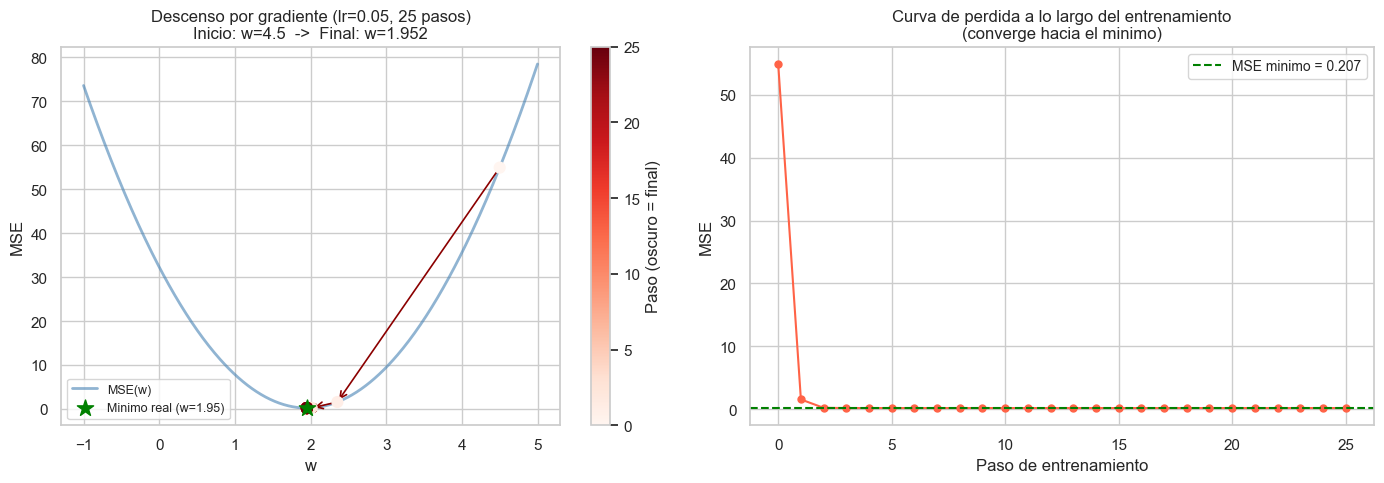

[OK] images/B02B_fig02.png

w inicial: 4.50  |  w final (paso 25): 1.9516  |  w optimo: 1.9474


In [3]:
def mse_func(w):
    return np.mean((w * x_toy - y_toy)**2)

def grad_mse(w):
    return 2 * np.mean(x_toy * (w * x_toy - y_toy))

# Descenso por gradiente manual
learning_rate = 0.05
n_pasos = 25
w_hist  = [4.5]   # punto de inicio

for _ in range(n_pasos):
    g = grad_mse(w_hist[-1])
    w_hist.append(w_hist[-1] - learning_rate * g)

mse_hist = [mse_func(w) for w in w_hist]

# Visualización: trayectoria sobre la curva de pérdida
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: trayectoria sobre la curva
axes[0].plot(w_vals, mse_vals, 'steelblue', linewidth=2, alpha=0.6, label='MSE(w)')
sc = axes[0].scatter(w_hist, mse_hist,
                     c=range(len(w_hist)), cmap='Reds', s=60, zorder=5)
for i in range(len(w_hist)-1):
    axes[0].annotate('', xy=(w_hist[i+1], mse_hist[i+1]),
                     xytext=(w_hist[i], mse_hist[i]),
                     arrowprops=dict(arrowstyle='->', color='darkred', lw=1.2))
axes[0].scatter([w_opt], [mse_opt], color='green', s=150, marker='*',
                zorder=6, label=f'Minimo real (w={w_opt:.2f})')
plt.colorbar(sc, ax=axes[0], label='Paso (oscuro = final)')
axes[0].set_xlabel('w'); axes[0].set_ylabel('MSE')
axes[0].set_title(f'Descenso por gradiente (lr={learning_rate}, {n_pasos} pasos)\nInicio: w=4.5  ->  Final: w={w_hist[-1]:.3f}')
axes[0].legend(fontsize=9)

# Panel 2: evolución del error a lo largo de los pasos
axes[1].plot(mse_hist, 'o-', color='tomato', markersize=5)
axes[1].axhline(mse_opt, color='green', linestyle='--', label=f'MSE minimo = {mse_opt:.3f}')
axes[1].set_xlabel('Paso de entrenamiento'); axes[1].set_ylabel('MSE')
axes[1].set_title('Curva de perdida a lo largo del entrenamiento\n(converge hacia el minimo)')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig('images/B02B_fig02.png', dpi=120, bbox_inches='tight')
plt.show()
print('[OK] images/B02B_fig02.png')
print(f'\nw inicial: 4.50  |  w final (paso {n_pasos}): {w_hist[-1]:.4f}  |  w optimo: {w_opt:.4f}')

**Lo que muestra esta simulación:**

- Cada punto rojo es un paso del algoritmo: el modelo calcula el gradiente (pendiente
  local de la curva) y da un pequeño paso hacia abajo.
- El panel derecho muestra cómo el error decrece con cada paso - esto es exactamente
  la "curva de pérdida de entrenamiento" que los frameworks como Keras o PyTorch
  muestran durante el entrenamiento.
- Después de ~15 pasos, el error ya no baja significativamente: el modelo ha convergido.

**Nota:** en este ejemplo con un solo parámetro, el mínimo es exactamente calculable.
En redes neuronales con millones de parámetros, el descenso por gradiente es la única
forma práctica de encontrar un mínimo razonablemente bueno.

---

## 3. MSE vs MAE: el impacto de los outliers en la función de pérdida

Las dos funciones de pérdida más comunes para regresión penalizan el error de forma
diferente:

- **MSE** (Mean Squared Error): eleva al cuadrado → penaliza exponencialmente los errores grandes
- **MAE** (Mean Absolute Error): valor absoluto → penaliza linealmente, más robusto a outliers

La elección entre ambas no es técnica: depende de si los valores extremos en el target
son casos reales que el modelo debe aprender a evitar, o son ruido/excepciones que
no se repetirán.

Modelo MSE  -> MSE=15.59  MAE=1.87
Modelo MAE  -> MSE=16.74  MAE=1.53

Observacion: el modelo MAE tiene mayor MSE (no penaliza tanto los outliers)
             pero menor MAE (error tipico en casos normales es menor)


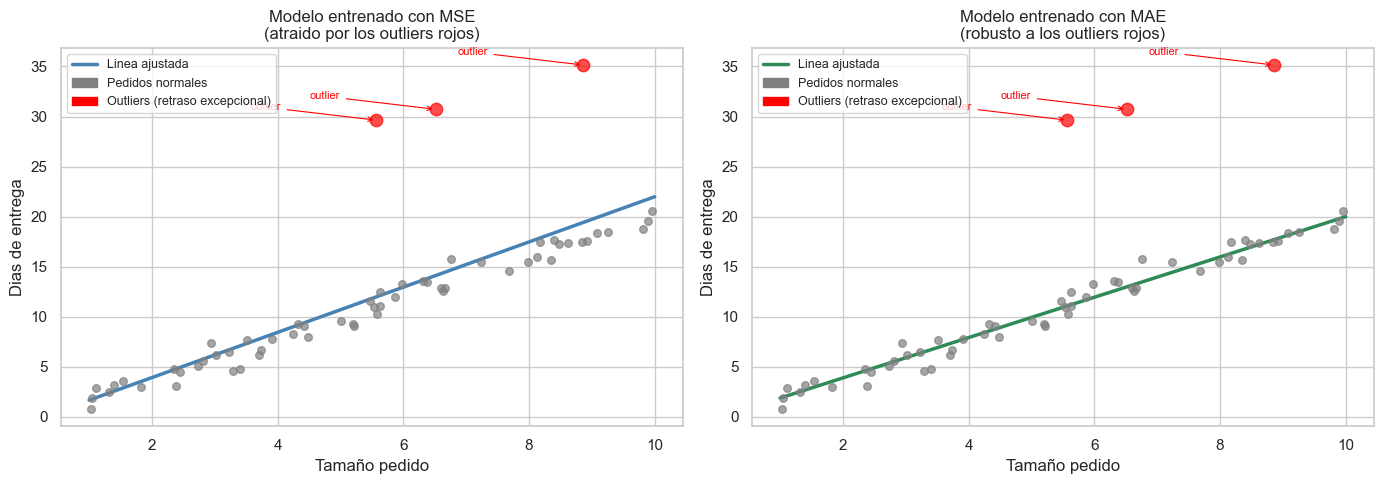

[OK] images/B02B_fig03.png


In [4]:
rng = np.random.default_rng(7)

# Dataset de entrega de pedidos la empresa (dias)
n = 60
x_entregas = rng.uniform(1, 10, n).reshape(-1, 1)  # tamaño del pedido
y_entregas  = 2.0 * x_entregas.ravel() + rng.normal(0, 1, n)

# Añadir 3 outliers (retrasos excepcionales: huelga de transporte)
outlier_idx = [5, 22, 48]
y_entregas[outlier_idx] += 18  # retraso de 18 dias adicionales

# Ajustar dos modelos: uno minimizando MSE, otro minimizando MAE
model_mse = LinearRegression()
model_mse.fit(x_entregas, y_entregas)
y_pred_mse = model_mse.predict(x_entregas)

# MAE: usamos HuberRegressor con epsilon muy grande para aproximar MAE
from sklearn.linear_model import HuberRegressor
model_mae = HuberRegressor(epsilon=1.0001)
model_mae.fit(x_entregas, y_entregas)
y_pred_mae = model_mae.predict(x_entregas)

# Métricas
mse_val = mean_squared_error(y_entregas, y_pred_mse)
mae_val = mean_absolute_error(y_entregas, y_pred_mse)
mse_val2 = mean_squared_error(y_entregas, y_pred_mae)
mae_val2 = mean_absolute_error(y_entregas, y_pred_mae)

print('Modelo MSE  -> MSE={:.2f}  MAE={:.2f}'.format(mse_val, mae_val))
print('Modelo MAE  -> MSE={:.2f}  MAE={:.2f}'.format(mse_val2, mae_val2))
print()
print('Observacion: el modelo MAE tiene mayor MSE (no penaliza tanto los outliers)')
print('             pero menor MAE (error tipico en casos normales es menor)')

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x_line2 = np.linspace(1, 10, 100).reshape(-1, 1)
colors = ['gray'] * n
for i in outlier_idx:
    colors[i] = 'red'

for ax, y_pred, titulo, color_line in [
    (axes[0], y_pred_mse, 'Modelo entrenado con MSE\n(atraido por los outliers rojos)', 'steelblue'),
    (axes[1], y_pred_mae, 'Modelo entrenado con MAE\n(robusto a los outliers rojos)', 'seagreen'),
]:
    for i, (xi, yi, ci) in enumerate(zip(x_entregas, y_entregas, colors)):
        ax.scatter(xi, yi, color=ci, s=30 if ci == 'gray' else 80,
                   zorder=3, alpha=0.7)
    ax.plot(x_line2, model_mse.predict(x_line2) if 'MSE' in titulo else model_mae.predict(x_line2),
            color=color_line, linewidth=2.5, label='Linea ajustada')
    ax.set_xlabel('Tamaño pedido'); ax.set_ylabel('Dias de entrega')
    ax.set_title(titulo)
    ax.legend(['Linea ajustada', 'Pedidos normales', 'Outliers (excepcionales)'],
              fontsize=9)
    # Anotación de outliers
    for i in outlier_idx:
        ax.annotate('outlier', xy=(x_entregas[i], y_entregas[i]),
                    xytext=(x_entregas[i][0]-2, y_entregas[i]+1),
                    fontsize=8, color='red',
                    arrowprops=dict(arrowstyle='->', color='red', lw=0.8))

# Añadir leyenda de outliers en rojo
red_patch  = mpatches.Patch(color='red',  label='Outliers (retraso excepcional)')
gray_patch = mpatches.Patch(color='gray', label='Pedidos normales')
for ax in axes:
    ax.legend(handles=[ax.get_lines()[0], gray_patch, red_patch], fontsize=9)

plt.tight_layout()
plt.savefig('images/B02B_fig03.png', dpi=120, bbox_inches='tight')
plt.show()
print('[OK] images/B02B_fig03.png')

**Tabla de decisión - MSE vs MAE:**

| Característica | MSE | MAE |
|---|---|---|
| Penalización de errores grandes | Cuadrática (muy fuerte) | Lineal (proporcional) |
| Sensibilidad a outliers | Alta | Baja |
| Diferenciabilidad | En todo punto | No diferenciable en 0 |
| Interpretabilidad | Error en unidades² | Error en las mismas unidades que el target |
| Cuándo usar | Outliers son casos reales a evitar | Outliers son ruido/excepciones |

**Ejemplo la empresa:** si los retrasos de 18 días son causados por una huelga de
transportistas (evento excepcional que no se repetirá con la misma frecuencia), usar
MSE hará que el modelo aprenda a "tener miedo" de esos pedidos aunque en el futuro
no haya huelga. MAE o Huber loss producen un modelo más útil en condiciones normales.

---

## 4. Cross-entropy: la función de pérdida para clasificación

Cuando el target es una categoría (churn/no churn, urgente/normal), la función de pérdida
no puede ser MSE: las categorías no tienen distancia aritmética. La **cross-entropy** mide
cuánta "sorpresa" produce la predicción del modelo cuando se revela la clase correcta.

```
Cross-entropy = -log(p_correcta)
```

Donde `p_correcta` es la probabilidad que el modelo asignó a la clase que resultó ser la real.

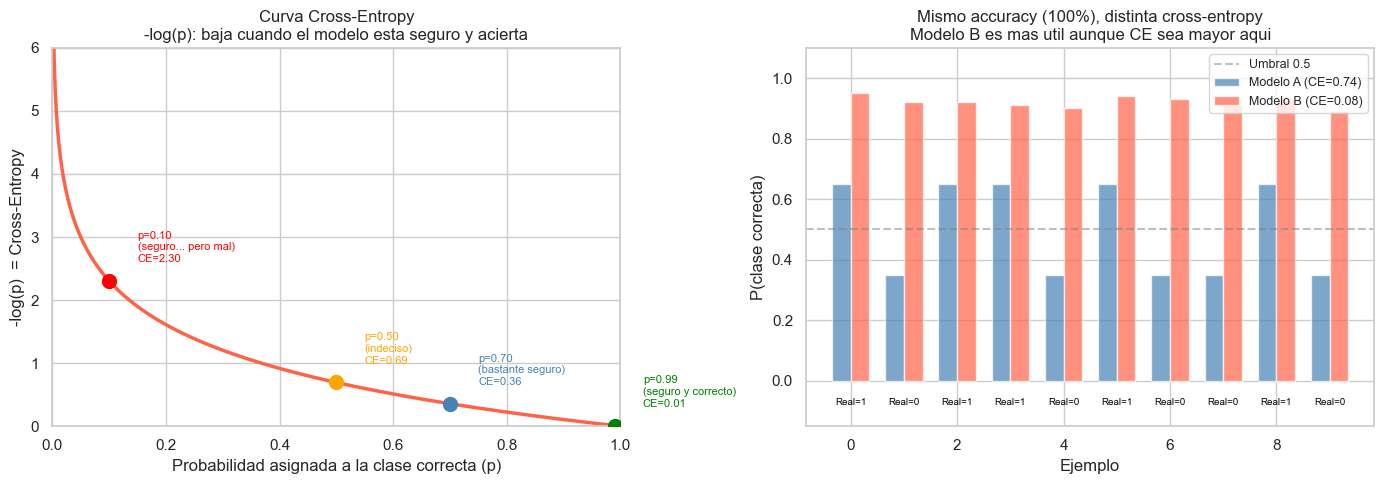

[OK] images/B02B_fig04.png

Modelo A: Accuracy=100%  CE=0.740
Modelo B: Accuracy=50%  CE=0.084

Modelo B tiene menor CE: sus probabilidades estan mejor calibradas.
Cuando acierta, lo hace con alta confianza. Cuando falla, lo sabemos porque la CE es alta.


In [5]:
p_vals = np.linspace(0.001, 0.999, 500)
ce_vals = -np.log(p_vals)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: curva -log(p)
axes[0].plot(p_vals, ce_vals, 'tomato', linewidth=2.5)
puntos = [(0.99, 'p=0.99\n(seguro y correcto)', 'green'),
          (0.70, 'p=0.70\n(bastante seguro)', 'steelblue'),
          (0.50, 'p=0.50\n(indeciso)', 'orange'),
          (0.10, 'p=0.10\n(seguro... pero mal)', 'red')]
for p, lbl, col in puntos:
    ce = -np.log(p)
    axes[0].scatter([p], [ce], color=col, s=100, zorder=5)
    axes[0].annotate(f'{lbl}\nCE={ce:.2f}',
                     xy=(p, ce), xytext=(p+0.05, ce+0.3),
                     fontsize=8, color=col)
axes[0].set_xlabel('Probabilidad asignada a la clase correcta (p)')
axes[0].set_ylabel('-log(p)  = Cross-Entropy')
axes[0].set_title('Curva Cross-Entropy\n-log(p): baja cuando el modelo esta seguro y acierta')
axes[0].set_xlim(0, 1); axes[0].set_ylim(0, 6)

# Panel 2: comparativa de dos modelos - mismo acierto, distinta confianza
# Modelo A: conservative (probabilities close to 0.6)
# Modelo B: confident (probabilities close to 0.95 or 0.05)
y_true = np.array([1, 0, 1, 1, 0, 1, 0, 0, 1, 0])  # 10 ejemplos

# Modelo A: predice con certeza moderada
p_modelo_A = np.where(y_true == 1, 0.65, 0.35)

# Modelo B: predice con alta certeza (pero a veces se equivoca con alta confianza)
p_modelo_B = np.where(y_true == 1,
                       np.array([0.95,0.08,0.92,0.91,0.10,0.94,0.07,0.09,0.93,0.11]),
                       np.array([0.05,0.92,0.08,0.09,0.90,0.06,0.93,0.91,0.07,0.89]))

ce_A = -np.mean(np.log(p_modelo_A))
ce_B = -np.mean(np.log(p_modelo_B))
acc_A = np.mean((p_modelo_A >= 0.5) == y_true)
acc_B = np.mean((p_modelo_B >= 0.5) == y_true)

x_idx = np.arange(10)
bar_w = 0.35
bars_A = axes[1].bar(x_idx - bar_w/2, p_modelo_A, bar_w,
                      color='steelblue', alpha=0.7, label=f'Modelo A (CE={ce_A:.2f})')
bars_B = axes[1].bar(x_idx + bar_w/2, p_modelo_B, bar_w,
                      color='tomato', alpha=0.7, label=f'Modelo B (CE={ce_B:.2f})')
axes[1].axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Umbral 0.5')
for i, yt in enumerate(y_true):
    axes[1].text(i, -0.08, 'Real=1' if yt else 'Real=0', ha='center', fontsize=7, color='black')
axes[1].set_ylim(-0.15, 1.1)
axes[1].set_xlabel('Ejemplo'); axes[1].set_ylabel('P(clase correcta)')
axes[1].set_title(f'Mismo accuracy ({acc_A:.0%}), distinta cross-entropy\nModelo B es mas util aunque CE sea mayor aqui')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('images/B02B_fig04.png', dpi=120, bbox_inches='tight')
plt.show()
print('[OK] images/B02B_fig04.png')
print(f'\nModelo A: Accuracy={acc_A:.0%}  CE={ce_A:.3f}')
print(f'Modelo B: Accuracy={acc_B:.0%}  CE={ce_B:.3f}')
print()
print('Modelo B tiene menor CE: sus probabilidades estan mejor calibradas.')
print('Cuando acierta, lo hace con alta confianza. Cuando falla, lo sabemos porque la CE es alta.')

---

## 5. Train loss vs. Validation loss: detectar sobreajuste

Durante el entrenamiento se calculan dos curvas:
- **Train loss**: error sobre los datos que el modelo SÍ vio (puede ir a cero si el modelo memoriza)
- **Val loss**: error sobre datos que el modelo NUNCA vio (refleja si generalizó o memorizó)

El sobreajuste (overfitting) es visible cuando train loss sigue bajando pero val loss sube.

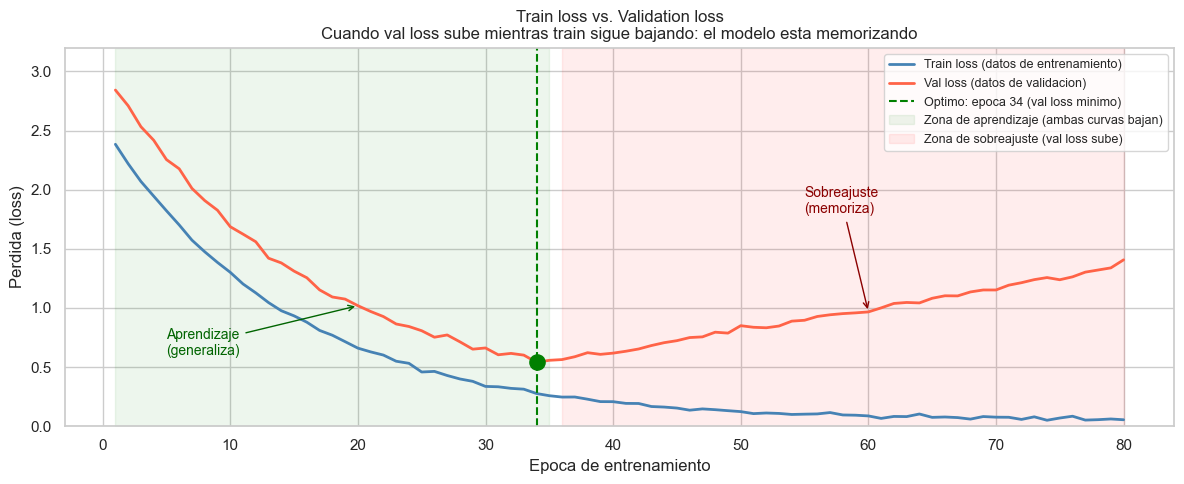

[OK] images/B02B_fig05.png

Epoca optima de parada: 34
Train loss en optimo: 0.2762
Val loss en optimo:   0.5407

REGLA: guardar el modelo en la epoca de minimo val loss, no al final del entrenamiento.


In [6]:
# Simulacion de curvas de entrenamiento: modelo que sobreajusta
n_epocas = 80
epocas   = np.arange(1, n_epocas + 1)

# Train loss: baja continuamente (modelo memoriza el train set)
train_loss = 2.5 * np.exp(-0.07 * epocas) + 0.05 + np.random.normal(0, 0.01, n_epocas)

# Val loss: baja al principio, luego sube (sobreajuste desde epoca ~35)
turning = 35
val_loss = np.zeros(n_epocas)
val_loss[:turning] = 2.8 * np.exp(-0.065 * epocas[:turning]) + 0.25 + np.random.normal(0, 0.02, turning)
val_loss[turning:] = (val_loss[turning-1]
                      + 0.018 * (epocas[turning:] - epocas[turning])
                      + np.random.normal(0, 0.015, n_epocas - turning))

val_min_ep = np.argmin(val_loss)

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(epocas, train_loss, 'steelblue', linewidth=2, label='Train loss (datos de entrenamiento)')
ax.plot(epocas, val_loss,   'tomato',    linewidth=2, label='Val loss (datos de validacion)')

# Marcar el punto optimo
ax.axvline(val_min_ep + 1, color='green', linestyle='--', linewidth=1.5,
           label=f'Optimo: epoca {val_min_ep+1} (val loss minimo)')
ax.scatter([val_min_ep + 1], [val_loss[val_min_ep]], color='green', s=120, zorder=5)

# Anotar zonas
ax.fill_between(epocas[:turning], 0, 3.2, alpha=0.07, color='green',
                label='Zona de aprendizaje (ambas curvas bajan)')
ax.fill_between(epocas[turning:], 0, 3.2, alpha=0.07, color='red',
                label='Zona de sobreajuste (val loss sube)')
ax.annotate('Sobreajuste\n(memoriza)', xy=(60, val_loss[59]),
            xytext=(55, 1.8), fontsize=10,
            arrowprops=dict(arrowstyle='->', color='darkred'), color='darkred')
ax.annotate('Aprendizaje\n(generaliza)', xy=(20, val_loss[19]),
            xytext=(5, 0.6), fontsize=10,
            arrowprops=dict(arrowstyle='->', color='darkgreen'), color='darkgreen')

ax.set_xlabel('Epoca de entrenamiento')
ax.set_ylabel('Perdida (loss)')
ax.set_ylim(0, 3.2)
ax.set_title('Train loss vs. Validation loss\nCuando val loss sube mientras train sigue bajando: el modelo esta memorizando')
ax.legend(fontsize=9, loc='upper right')

plt.tight_layout()
plt.savefig('images/B02B_fig05.png', dpi=120, bbox_inches='tight')
plt.show()
print('[OK] images/B02B_fig05.png')
print(f'\nEpoca optima de parada: {val_min_ep+1}')
print(f'Train loss en optimo: {train_loss[val_min_ep]:.4f}')
print(f'Val loss en optimo:   {val_loss[val_min_ep]:.4f}')
print()
print('REGLA: guardar el modelo en la epoca de minimo val loss, no al final del entrenamiento.')

**Para el perfil de negocio:** la época óptima de parada (donde val loss es mínimo) es
el punto donde el modelo tiene el mejor equilibrio entre aprender el patrón real y no
memorizar el histórico. Pedir siempre estas dos curvas al equipo técnico. Un proveedor
que solo muestra train loss está ocultando si el modelo funcionará en producción.

**Para el perfil técnico:** el fenómeno se llama **early stopping**: se monitoriza val loss
durante el entrenamiento y se detiene cuando lleva N épocas sin mejorar. En Keras/PyTorch
es un callback estándar:
```python
from keras.callbacks import EarlyStopping
cb = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
```

---

## 6. Exploración interactiva: comparativa de funciones de pérdida

El gráfico interactivo permite comparar cómo distintas funciones de pérdida responden
a errores de distintos tamaños. Pasa el cursor para ver los valores exactos.

In [7]:
err_vals = np.linspace(0, 6, 300)
mse_  = err_vals**2
mae_  = err_vals
huber_ = np.where(np.abs(err_vals) <= 1,
                  0.5 * err_vals**2,
                  np.abs(err_vals) - 0.5)

fig_px = go.Figure()
fig_px.add_trace(go.Scatter(x=err_vals, y=mse_,   mode='lines',
    name='MSE (cuadratico)',   line=dict(color='steelblue', width=2.5)))
fig_px.add_trace(go.Scatter(x=err_vals, y=mae_,   mode='lines',
    name='MAE (lineal)',       line=dict(color='seagreen',  width=2.5, dash='dash')))
fig_px.add_trace(go.Scatter(x=err_vals, y=huber_, mode='lines',
    name='Huber (hibrido)',    line=dict(color='tomato',    width=2.5, dash='dot')))
fig_px.add_vline(x=1, line_dash='dot', line_color='gray',
    annotation_text='delta=1 (Huber transition)', annotation_position='top right')

fig_px.update_layout(
    title='Comparativa de funciones de perdida para regresion<br>(eje X = error = |prediccion - real|)',
    xaxis_title='Magnitud del error',
    yaxis_title='Penalizacion (loss)',
    height=450,
    legend=dict(x=0.02, y=0.98),
    hovermode='x unified'
)
fig_px.show()

try:
    fig_px.write_image('images/B02B_fig06.png', scale=2)
    print('[OK] images/B02B_fig06.png')
except Exception:
    fig_px.write_html('images/B02B_fig06.html')
    print('[OK] images/B02B_fig06.html  (kaleido no disponible)')

print()
print('Observacion: para error = 4:')
print(f'  MSE   = {4**2:.0f}  (penalizacion muy alta)')
print(f'  MAE   = {4:.0f}    (penalizacion lineal)')
print(f'  Huber = {4-0.5:.1f}  (entre ambos)')

[OK] images/B02B_fig06.html  (kaleido no disponible)

Observacion: para error = 4:
  MSE   = 16  (penalizacion muy alta)
  MAE   = 4    (penalizacion lineal)
  Huber = 3.5  (entre ambos)


---

## Ejercicio técnico: calcular MSE a mano y comparar con sklearn

**Enunciado:** dado un modelo que predice días de entrega de pedidos la empresa,
calcular manualmente el MSE y compararlo con el resultado de sklearn.
Después, identificar qué pedidos contribuyen más al error total.

In [8]:
# Datos del ejercicio (ya preparados)
y_real     = np.array([3, 5, 4, 7, 2, 8, 3, 6, 4, 9], dtype=float)
y_predicho = np.array([3.5, 4.8, 4.2, 6.1, 2.8, 9.5, 2.9, 5.7, 4.4, 7.2])

print('Pedido  | Dias reales | Dias predichos | Error')
print('-' * 50)
for i, (r, p) in enumerate(zip(y_real, y_predicho)):
    print(f'  {i+1:2d}    |     {r:.0f}       |      {p:.1f}        | {r-p:+.1f}')

Pedido  | Dias reales | Dias predichos | Error
--------------------------------------------------
   1    |     3       |      3.5        | -0.5
   2    |     5       |      4.8        | +0.2
   3    |     4       |      4.2        | -0.2
   4    |     7       |      6.1        | +0.9
   5    |     2       |      2.8        | -0.8
   6    |     8       |      9.5        | -1.5
   7    |     3       |      2.9        | +0.1
   8    |     6       |      5.7        | +0.3
   9    |     4       |      4.4        | -0.4
  10    |     9       |      7.2        | +1.8


In [9]:
# TODO: calcular MSE manualmente

# Paso 1: calcular el error para cada pedido (y_real - y_predicho)
# errores = ...

# Paso 2: elevar al cuadrado cada error
# errores_cuadrado = ...

# Paso 3: calcular la media
# mse_manual = ...

# Paso 4: comparar con sklearn
# from sklearn.metrics import mean_squared_error
# mse_sklearn = mean_squared_error(y_real, y_predicho)

# Paso 5: identificar el pedido que mas contribuye al MSE
# pedido_peor = ...

# PISTA: el pedido 6 (entrega de 9.5 dias vs. real 8 dias) deberia ser el mayor contribuidor
print('Completa el codigo y ejecuta esta celda.')

Completa el codigo y ejecuta esta celda.


In [10]:
# SOLUCION COMENTADA

# Paso 1: errores individuales
errores = y_real - y_predicho

# Paso 2: cuadrados
errores_sq = errores**2

# Paso 3: media
mse_manual = errores_sq.mean()

# Paso 4: verificacion con sklearn
mse_sklearn = mean_squared_error(y_real, y_predicho)

# Paso 5: pedido que mas contribuye
pedido_peor = np.argmax(errores_sq) + 1
contribucion_pct = errores_sq[pedido_peor-1] / errores_sq.sum() * 100

print('Errores por pedido:')
for i, (e, eq) in enumerate(zip(errores, errores_sq)):
    barra = '#' * int(eq * 5)
    print(f'  Pedido {i+1:2d}: error={e:+.1f}  error^2={eq:.2f}  {barra}')
print()
print(f'MSE manual:  {mse_manual:.4f}')
print(f'MSE sklearn: {mse_sklearn:.4f}  [verificacion OK: {"si" if abs(mse_manual-mse_sklearn)<1e-9 else "revisar"}]')
print(f'RMSE:        {np.sqrt(mse_manual):.4f}  (en las mismas unidades que dias de entrega)')
print()
print(f'Pedido que mas contribuye al MSE: Pedido {pedido_peor}')
print(f'  Contribucion: {contribucion_pct:.1f}% del error total')
print()
print('Interpretacion:')
print('  El RMSE de {:.2f} dias significa que en promedio el modelo se equivoca'.format(np.sqrt(mse_manual)))
print('  esa cantidad de dias. Pero el MSE esta dominado por el Pedido {}.'.format(pedido_peor))
print('  Si ese pedido es un outlier (no representativo), considerar MAE.')

Errores por pedido:
  Pedido  1: error=-0.5  error^2=0.25  #
  Pedido  2: error=+0.2  error^2=0.04  
  Pedido  3: error=-0.2  error^2=0.04  
  Pedido  4: error=+0.9  error^2=0.81  ####
  Pedido  5: error=-0.8  error^2=0.64  ###
  Pedido  6: error=-1.5  error^2=2.25  ###########
  Pedido  7: error=+0.1  error^2=0.01  
  Pedido  8: error=+0.3  error^2=0.09  
  Pedido  9: error=-0.4  error^2=0.16  
  Pedido 10: error=+1.8  error^2=3.24  ################

MSE manual:  0.7530
MSE sklearn: 0.7530  [verificacion OK: si]
RMSE:        0.8678  (en las mismas unidades que dias de entrega)

Pedido que mas contribuye al MSE: Pedido 10
  Contribucion: 43.0% del error total

Interpretacion:
  El RMSE de 0.87 dias significa que en promedio el modelo se equivoca
  esa cantidad de dias. Pero el MSE esta dominado por el Pedido 10.
  Si ese pedido es un outlier (no representativo), considerar MAE.


---

## Ejercicio de decisión (sin código)

**Caso:** el equipo de operaciones de la empresa quiere un modelo que prediga el tiempo
de entrega (en días) de cada pedido. Tras analizar el histórico, encuentran que:

- El 85% de los pedidos se entregan en 2-8 días (distribución normal, poca varianza).
- El 15% restante tiene retrasos de 15-30 días, siempre causados por uno de estos motivos:
  (a) proveedor internacional con stock bajo, (b) error de almacén corregido manualmente.
- Los motivos (a) y (b) están registrados en el ERP como campos separados.

El equipo técnico propone usar MSE como función de pérdida.

---

**Preguntas:**

1. ¿Estarías de acuerdo con usar MSE en este caso? ¿Por qué sí o por qué no?
2. ¿Qué información adicional del ERP cambiaría tu decisión?
3. Si los retrasos excepcionales son conocidos en el momento de hacer el pedido
   (el proveedor ya avisó del stock bajo), ¿cambia tu respuesta?
4. ¿Tiene sentido aquí usar IA para predecir entregas, o sería suficiente una regla
   de negocio determinista?

**Espacio para argumentar:**

> [escribe tu razonamiento aquí]

---

<details>
<summary>Criterios de evaluación (desplegar tras el ejercicio)</summary>

**Respuesta madura incluye:**

1. Argumentar en contra del MSE: el 15% de outliers dominará la función de pérdida
   y el modelo aprenderá principalmente de esos casos excepcionales. MAE o Huber son
   más adecuados para el 85% normal.

2. La clave está en si los campos (a) y (b) están disponibles en el momento de predecir.
   Si están disponibles, pueden ser features directas que explican el retraso - 
   y el problema se simplifica enormemente.

3. Si el retraso excepcional ya es conocido (el proveedor avisó), NO hay nada que
   predecir: el retraso es observable antes de que ocurra. En ese caso, no se necesita
   un modelo: se necesita integrar esa información en el proceso de confirmación de pedido.

4. Si los retrasos excepcionales son predecibles por reglas (proveedor X siempre tarda
   más de 10 días cuando el stock de su almacén es < Y unidades), una regla determinista
   puede ser más fiable que un modelo. El ML se justifica cuando la combinación de variables
   que predice el retraso no es capturablecon una regla simple.

**Señal de comprensión:** el alumno no responde "MSE sí" o "MAE no" de forma absoluta,
sino que condiciona la respuesta a si los outliers son evitables con información disponible.

</details>

---

## Assets generados

| Archivo | Contenido |
|---|---|
| `images/B02B_fig01.png` | Curva de pérdida convexa + lineas ajustadas con distinto w |
| `images/B02B_fig02.png` | Descenso por gradiente: trayectoria sobre curva + evolución del error |
| `images/B02B_fig03.png` | MSE vs MAE: impacto de outliers en la línea ajustada (la empresa) |
| `images/B02B_fig04.png` | Cross-entropy: curva logarítmica + comparativa dos modelos mismo accuracy |
| `images/B02B_fig05.png` | Train loss vs. validation loss con zona de sobreajuste marcada |
| `images/B02B_fig06.png / .html` | Plotly interactivo: MSE vs MAE vs Huber comparativa |

**Dependencias:** numpy, pandas, matplotlib, seaborn, scipy, sklearn, plotly